In [ ]:
import torch
print(torch.__version__)

In [ ]:
import torch
x=torch.rand(5,3)
print(x)

In [ ]:
import torch
x=torch.arange(12)
print(x)

In [ ]:
x.shape

In [ ]:
x.numel()

In [ ]:
X=x.reshape(3,4)
print(X)

In [ ]:
torch.randn(3,4)

In [ ]:
x=torch.arange(12,dtype=torch.float32).reshape(3,4)
y=torch.tensor([[2.0,1,4,3],[1,2,3,4],[4,3,2,1]])
torch.cat((x,y),dim=0),torch.cat((x,y),dim=1) #merge by row and column separately

In [ ]:
x[-1],x[1:3]

In [ ]:
before=id(y)
y=x+y
id(y)==before

In [ ]:
z=torch.zeros_like(y)
print('id(z):',id(z))
z[:]=x+y
print('id(z):',id(z))

In [1]:
import os

os.makedirs('data',exist_ok=True)
data_file=os.path.join('data','house_tiny.csv')
with open(data_file,'w') as f:
    f.write('NumRooms,Alley,Price\n')
    f.write('NA,Pave,127500\n')
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')

In [2]:
import pandas as pd

data=pd.read_csv(data_file)
print(data)

   NumRooms Alley   Price
0       NaN  Pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000


In [3]:
inputs,outputs=data.iloc[:,0:2],data.iloc[:,2]
# separate numerical column and classification column
num_cols = ['NumRooms']          # or inputs.select_dtypes(include=['float','int']).columns

# fill the numerical column with the mean value
inputs[num_cols] = inputs[num_cols].fillna(inputs[num_cols].mean())
print(inputs)

   NumRooms Alley
0       3.0  Pave
1       2.0   NaN
2       4.0   NaN
3       3.0   NaN


In [4]:
inputs=pd.get_dummies(inputs,dummy_na=True)
print(inputs)

   NumRooms  Alley_Pave  Alley_nan
0       3.0        True      False
1       2.0       False       True
2       4.0       False       True
3       3.0       False       True


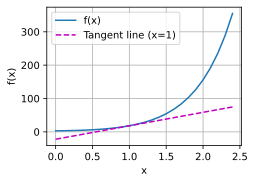

In [10]:
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l

def f(x):
    return 3*np.exp(2*x)-4*x

x=np.arange(0,2.5,0.1)
d2l.plot(x,[f(x),(6*np.exp(2)-4)*x-3*np.exp(2)],'x','f(x)',legend=['f(x)','Tangent line (x=1)'])


In [6]:
import torch
x=torch.arange(4.0,requires_grad=True)
y=2*torch.dot(x,x)
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [7]:
x.grad==4*x

tensor([True, True, True, True])

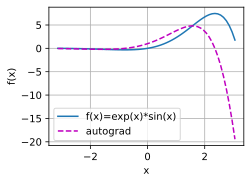

In [21]:
import torch
from matplotlib_inline import backend_inline
from d2l import torch as d2l

def f(x):
    return torch.sin(x)*torch.exp(x)

x=torch.arange(-1*np.pi,1*np.pi,0.1,requires_grad=True)

y=f(x)
y.backward(torch.ones_like(y))
dy_dx=x.grad

d2l.plot(x.detach().numpy(),[y.detach().numpy(),dy_dx.detach().numpy()],'x','f(x)',legend=['f(x)=exp(x)*sin(x)','autograd'])